<a href="https://colab.research.google.com/github/fralfaro/MAT281/blob/main/docs/labs/lab_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# MAT281 - Laboratorio N°08

**Objetivo**: Aplicar técnicas de **machine learning no supervisado** para explorar, procesar y analizar conjuntos de datos con variables numéricas y categóricas.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.


## Clustering


<img src="https://www.svgrepo.com/show/253022/car.svg" width = "300" align="center"/>



El conjunto de datos **`vehiculos_procesado_con_grupos.csv`** recopila información sobre diversas características relevantes de distintos vehículos. El propósito de este ejercicio es **clasificar los vehículos en diferentes categorías**, utilizando como base las variables descritas en la tabla de atributos.

El análisis presenta un desafío adicional debido a la **naturaleza mixta de los datos**: se incluyen tanto variables **numéricas** (ej. dimensiones, consumo, emisiones) como **categóricas** (ej. tipo de tracción, tipo de combustible), lo que requiere aplicar técnicas de preprocesamiento adecuadas antes de entrenar los modelos.

Como primer paso, procederemos a **cargar y explorar el conjunto de datos**, con el fin de familiarizarnos con su estructura y las características que servirán como base para la posterior clasificación.




**Descripción de los Datos:**

| **Nombre de la Columna**   | **Descripción**                                                                                                                                   |
|----------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------|
| **year**                   | El año en que el vehículo fue fabricado.                                                                                                          |
| **desplazamiento**          | La capacidad volumétrica del motor en litros. Indica la cantidad de aire y combustible que puede desplazar el motor durante una revolución.       |
| **cilindros**               | El número de cilindros que tiene el motor. Los cilindros son las cámaras donde ocurre la combustión interna en los motores de los vehículos.       |
| **co2**                     | Emisiones de dióxido de carbono del vehículo, medido en gramos por kilómetro. Es una medida de las emisiones de gases de efecto invernadero.       |
| **clase_tipo**              | La clase o tipo de vehículo, como vehículos especiales, deportivos, etc.                                                                         |
| **traccion_tipo**           | Tipo de tracción del vehículo, ya sea tracción en dos ruedas, en cuatro ruedas o en todas las ruedas.                                             |
| **transmision_tipo**        | Tipo de transmisión del vehículo, como automática, manual, entre otros.                                                                          |
| **combustible_tipo**        | Tipo de combustible que utiliza el vehículo, como gasolina, diésel, eléctrico, híbrido, etc.                                                     |
| **tamano_motor_tipo**       | Clasificación del tamaño del motor (por ejemplo, pequeño, mediano o grande), que generalmente se basa en la capacidad de desplazamiento.           |
| **consumo_tipo**            | Clasificación del nivel de consumo de combustible del vehículo, indicando si es alto, bajo, o muy alto.                                           |
| **co2_tipo**                | Clasificación de las emisiones de CO2 del vehículo, indicando si es alto, bajo, o muy alto.                                                       |
| **consumo_litros_milla**    | El consumo de combustible del vehículo, medido en litros por milla. Indica la eficiencia del vehículo en términos de consumo de combustible.        |



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans


%matplotlib inline

sns.set_palette("deep", desat=.6)
sns.set(rc={'figure.figsize':(11.7,8.27)})

In [2]:
# cargar datos
df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/MAT281/main/docs/labs/data/vehiculos_procesado_con_grupos.csv", sep=",")\
       .drop(
            ["fabricante",
             "modelo",
             "transmision",
             "traccion",
             "clase",
             "combustible",
             "consumo"],

          axis=1)

df.head()

,year,desplazamiento,cilindros,co2,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo,consumo_litros_milla
0,1984,2.5,4.0,522.764706,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.222671
1,1984,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
2,1985,2.5,4.0,555.437500,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.236588
3,1985,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
4,1987,3.8,6.0,555.437500,Coches Medianos,dos,Automatica,Premium,grande,alto,alto,0.236588


En este caso, no solo se tienen datos numéricos, sino que también categóricos. Además, tenemos problemas de datos **vacíos (Nan)**. Así que para resolver este problema, seguiremos varios pasos:

### 1.- Normalizar datos

- Cree un conjunto de datos con las variables numéricas, además, para cada dato vacía, rellene con el promedio asociado a esa columna. Finalmente, normalize los datos mediante el procesamiento **MinMaxScaler** de **sklearn**.
- Cree un conjunto de datos con las variables categóricas , además, transforme de variables categoricas a numericas ocupando el comando **get_dummies** de pandas ([referencia](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html)). Explique a grande rasgo como se realiza la codificación de variables numéricas a categóricas.

- Junte ambos dataset en uno, llamado **df_procesado**.

In [11]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1.- Normalizar datos

# Identificar variables numéricas y categóricas
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Crear un conjunto de datos con las variables numéricas
df_numeric = df[numeric_cols].copy()

# Rellenar valores vacíos con el promedio de la columna
for col in df_numeric.columns:
    if df_numeric[col].isnull().any():
        df_numeric[col] = df_numeric[col].fillna(df_numeric[col].mean())

# Normalizar los datos mediante MinMaxScaler
scaler = MinMaxScaler()
df_numeric_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=df_numeric.columns, index=df_numeric.index)

# Crear un conjunto de datos con las variables categóricas
df_categorical = df[categorical_cols].copy()

# Transformar variables categóricas a numéricas usando get_dummies
df_categorical_encoded = pd.get_dummies(df_categorical, drop_first=False)

# Explicación de get_dummies:
# `pd.get_dummies` convierte variables categóricas en una representación numérica binaria.
# Por cada columna categórica, crea nuevas columnas binarias (dummies).
# Si una columna categórica tiene `k` valores únicos, se crearán `k` nuevas columnas.
# Cada una de estas nuevas columnas corresponderá a uno de los valores únicos originales.
# Para cada fila, la columna correspondiente al valor original de esa fila tendrá un 1, y el resto de las columnas dummy para esa categoría tendrán un 0.
# Por ejemplo, si tenemos una columna 'color' con valores 'rojo', 'azul', 'verde', `get_dummies` crearía tres nuevas columnas: 'color_rojo', 'color_azul', 'color_verde'.
# Si una fila original tiene 'rojo', en las nuevas columnas sería [1, 0, 0].
# El argumento `drop_first=False` significa que no se elimina la primera columna dummy creada para evitar la multicolinealidad, manteniendo todas las categorías explicitas.

# Juntar ambos datasets en uno, llamado df_procesado
df_procesado = pd.concat([df_numeric_scaled, df_categorical_encoded], axis=1)

print("Primeras 5 filas de df_numeric_scaled:")
display(df_numeric_scaled.head())
print("Primeras 5 filas de df_categorical_encoded:")
display(df_categorical_encoded.head())
print("Primeras 5 filas de df_procesado:")
display(df_procesado.head())
print("Información general de df_procesado:")
df_procesado.info()

Primeras 5 filas de df_numeric_scaled:


,year,desplazamiento,cilindros,co2,consumo_litros_milla
0,0.000000,0.243590,0.142857,0.398014,0.331027
1,0.000000,0.461538,0.285714,0.527672,0.475113
2,0.029412,0.243590,0.142857,0.424351,0.360294
3,0.029412,0.461538,0.285714,0.527672,0.475113
4,0.088235,0.410256,0.285714,0.424351,0.360294


Primeras 5 filas de df_categorical_encoded:


,clase_tipo_Camionetas,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,clase_tipo_Deportivos,clase_tipo_Furgoneta,clase_tipo_Vehículos Especiales,traccion_tipo_cuatro,traccion_tipo_dos,...,consumo_tipo_alto,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_alto,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
0,False,False,False,False,False,False,False,True,False,True,...,True,False,False,False,False,True,False,False,False,False
1,False,False,False,False,False,False,False,True,False,True,...,False,False,False,True,False,False,False,False,True,False
2,False,False,False,False,False,False,False,True,False,True,...,True,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,True,False,True,...,False,False,False,True,False,False,False,False,True,False
4,False,False,False,True,False,False,False,False,False,True,...,True,False,False,False,False,True,False,False,False,False


Primeras 5 filas de df_procesado:


,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Camionetas,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,...,consumo_tipo_alto,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_alto,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
0,0.000000,0.243590,0.142857,0.398014,0.331027,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
1,0.000000,0.461538,0.285714,0.527672,0.475113,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0.029412,0.243590,0.142857,0.424351,0.360294,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
3,0.029412,0.461538,0.285714,0.527672,0.475113,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
4,0.088235,0.410256,0.285714,0.424351,0.360294,False,False,False,True,False,...,True,False,False,False,False,True,False,False,False,False


Información general de df_procesado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36791 entries, 0 to 36790
Data columns (total 36 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   year                                         36791 non-null  float64
 1   desplazamiento                               36791 non-null  float64
 2   cilindros                                    36791 non-null  float64
 3   co2                                          36791 non-null  float64
 4   consumo_litros_milla                         36791 non-null  float64
 5   clase_tipo_Camionetas                        36791 non-null  bool   
 6   clase_tipo_Coche Familiar                    36791 non-null  bool   
 7   clase_tipo_Coches Grandes                    36791 non-null  bool   
 8   clase_tipo_Coches Medianos                   36791 non-null  bool   
 9   clase_tipo_Coches pequeños         

### 2.- Realizar ajuste mediante kmeans

Una vez depurado el conjunto de datos, es momento de aplicar el algoritmo de **kmeans**.

1. Ajuste el modelo de **kmeans** sobre el conjunto de datos, con un total de **8 clusters**.
2. Asociar a cada individuo el correspondiente cluster y calcular valor de los centroides de cada cluster.
3. Realizar un resumen de las principales cualidades de cada cluster. Para  esto debe calcular (para cluster) las siguientes medidas de resumen:
    * Valor promedio de las variables numérica
    * Moda para las variables numericas

In [12]:
# 2.- Realizar ajuste mediante kmeans

# 1. Ajuste el modelo de kmeans sobre el conjunto de datos, con un total de 8 clusters.
kmeans_model = KMeans(n_clusters=8, random_state=42, n_init='auto') # n_init='auto' para evitar warnings
kmeans_model.fit(df_procesado)

# 2. Asociar a cada individuo el correspondiente cluster y calcular valor de los centroides de cada cluster.
df_clustered = df_procesado.copy()
df_clustered['cluster'] = kmeans_model.labels_

centroids = pd.DataFrame(kmeans_model.cluster_centers_, columns=df_procesado.columns)
centroids.index.name = 'cluster'

print("Centros de los clusters:")
display(centroids)

# 3. Realizar un resumen de las principales cualidades de cada cluster.

print("\n--- Resumen de Cualidades de Cada Cluster ---")

# a) Valor promedio de las variables numéricas
print("\nValores promedio de variables numéricas por cluster:")
cluster_numeric_means = df_clustered.groupby('cluster')[numeric_cols].mean()
display(cluster_numeric_means)

# b) Moda para las variables categóricas
print("\nModa de variables categóricas por cluster:")

cluster_categorical_modes = pd.DataFrame(index=range(kmeans_model.n_clusters), columns=categorical_cols)

for cluster_id in range(kmeans_model.n_clusters):
    cluster_data = df_clustered[df_clustered['cluster'] == cluster_id]
    for original_feature in categorical_cols:
        # Encontrar todas las columnas dummy relacionadas con esta característica original
        dummy_cols_for_feature = [col for col in df_procesado.columns if col.startswith(f'{original_feature}_')]
        if dummy_cols_for_feature:
            # La columna dummy con la suma más alta representa la moda (categoría más frecuente)
            mode_series = cluster_data[dummy_cols_for_feature].sum().idxmax()
            # Extraer el nombre de la categoría del nombre de la columna dummy
            category_name = mode_series.replace(f'{original_feature}_', '')
            cluster_categorical_modes.loc[cluster_id, original_feature] = category_name
        else:
            cluster_categorical_modes.loc[cluster_id, original_feature] = 'N/A'

display(cluster_categorical_modes)


Centros de los clusters:


,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Camionetas,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,...,consumo_tipo_alto,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_alto,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.374994,0.314506,0.244536,0.354640,0.281407,2.041199e-01,0.064045,0.004120,0.080524,0.494382,...,1.693090e-15,1.647940e-02,9.801498e-01,8.965051e-15,3.370787e-03,2.247191e-02,7.216450e-16,9.775281e-01,4.551914e-15,-1.196265e-14
1,0.695630,0.178857,0.150271,0.240158,0.156818,1.129652e-14,0.110562,0.027836,0.182362,0.547867,...,7.660539e-15,-1.265654e-14,2.601457e-04,1.321165e-14,9.997399e-01,1.060263e-14,1.742976e-02,-1.082467e-14,-9.325873e-15,9.825702e-01
2,0.440116,0.361599,0.287553,0.354467,0.281434,8.043324e-02,0.090732,0.128551,0.203125,0.297585,...,8.877841e-04,3.142756e-02,9.621804e-01,3.551136e-04,5.149148e-03,1.420455e-02,7.102273e-04,9.850852e-01,-1.196265e-14,-8.354428e-15
3,0.523869,0.250495,0.195088,0.304375,0.226729,6.144330e-02,0.095395,0.045636,0.153402,0.450172,...,-1.199041e-14,9.806186e-01,-2.603473e-14,-9.048318e-15,1.938144e-02,-8.743006e-15,9.989003e-01,5.498282e-04,7.216450e-15,5.498282e-04
4,0.412004,0.576146,0.420130,0.506937,0.449663,3.338947e-01,0.003789,0.035649,0.038596,0.138667,...,4.028070e-02,-1.662559e-14,8.982456e-03,9.507368e-01,-6.716849e-15,9.824561e-04,-3.144707e-14,-1.315614e-14,9.990175e-01,1.193490e-14
5,0.438752,0.159481,0.141102,0.242174,0.156452,1.642996e-02,0.125035,0.006405,0.092453,0.710387,...,6.716849e-15,-1.201816e-14,1.709743e-14,1.254552e-14,1.000000e+00,9.631185e-15,2.784740e-03,-1.043610e-14,-7.077672e-15,9.972153e-01
6,0.476203,0.446766,0.325461,0.410605,0.344917,3.053603e-01,0.017575,0.039543,0.048770,0.154657,...,9.872583e-01,-1.398881e-14,1.186292e-02,8.787346e-04,-6.550316e-15,9.925308e-01,6.590510e-04,-1.160183e-14,6.810193e-03,-1.745826e-14
7,0.723876,0.352314,0.282860,0.352799,0.279757,7.897241e-02,0.083730,0.098002,0.121789,0.184110,...,9.514748e-04,6.327307e-02,9.162702e-01,5.218048e-15,1.950523e-02,4.614653e-02,1.379638e-02,9.305423e-01,1.427212e-03,8.087536e-03



--- Resumen de Cualidades de Cada Cluster ---

Valores promedio de variables numéricas por cluster:


,year,desplazamiento,cilindros,co2,consumo_litros_milla
cluster,,,,,
0,0.375242,0.314568,0.244567,0.354655,0.281424
1,0.695630,0.178857,0.150271,0.240158,0.156818
2,0.440116,0.361599,0.287553,0.354467,0.281434
3,0.523869,0.250495,0.195088,0.304375,0.226729
4,0.412004,0.576146,0.420130,0.506937,0.449663
5,0.438752,0.159481,0.141102,0.242174,0.156452
6,0.476203,0.446766,0.325461,0.410605,0.344917
7,0.723894,0.352271,0.282857,0.352779,0.279733



Moda de variables categóricas por cluster:


,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo
0,Coches pequeños,dos,Manual,Normal,mediano,moderado,moderado
1,Coches pequeños,dos,Automatica,Normal,muy pequeño,muy bajo,muy bajo
2,Coches pequeños,dos,Automatica,Normal,mediano,moderado,moderado
3,Coches pequeños,dos,Automatica,Normal,pequeño,bajo,bajo
4,Camionetas,dos,Automatica,Normal,muy grande,muy alto,muy alto
5,Coches pequeños,dos,Manual,Normal,muy pequeño,muy bajo,muy bajo
6,Camionetas,dos,Automatica,Normal,grande,alto,alto
7,Deportivos,cuatro,Automatica,Premium,mediano,moderado,moderado


### 3.- Elegir Número de cluster

Estime mediante la **regla del codo**, el número de cluster apropiados para el caso.
Para efectos prácticos, eliga la siguiente secuencia como número de clusters a comparar:

$$[5, 10, 20, 30, 50, 75, 100, 200, 300]$$

Una vez realizado el gráfico, saque sus propias conclusiones del caso.

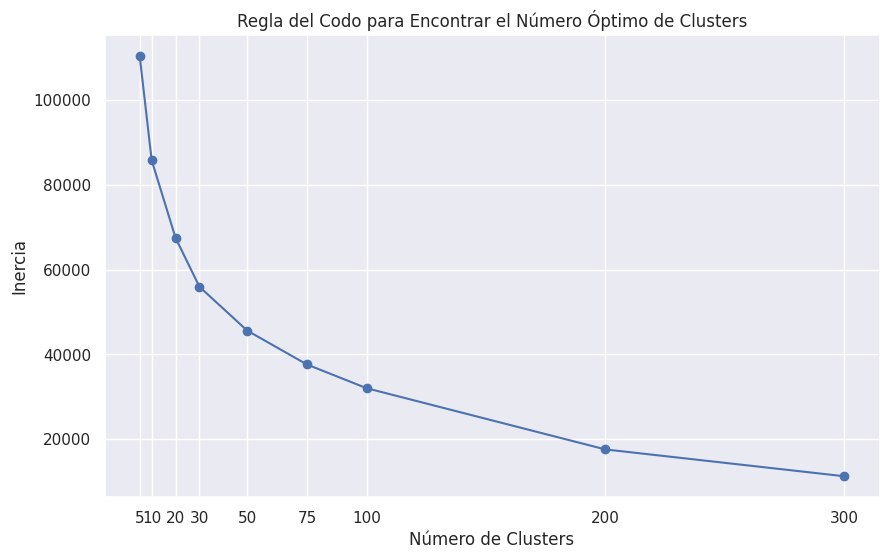

Valores de Inercia para diferentes números de clusters:
  Clusters: 5, Inercia: 110264.16
  Clusters: 10, Inercia: 85768.49
  Clusters: 20, Inercia: 67474.61
  Clusters: 30, Inercia: 55953.93
  Clusters: 50, Inercia: 45623.67
  Clusters: 75, Inercia: 37649.73
  Clusters: 100, Inercia: 32052.97
  Clusters: 200, Inercia: 17625.99
  Clusters: 300, Inercia: 11309.27

Para interpretar el gráfico de la regla del codo, se busca el punto en el que la curva de la inercia comienza a aplanarse, formando una especie de 'codo'. Este punto sugiere el número óptimo de clusters, ya que añadir más clusters después de este punto no proporciona una mejora significativa en la cohesión de los clusters (reducción de la inercia).


In [13]:
inertia = []
clusters_range = [5, 10, 20, 30, 50, 75, 100, 200, 300]

for n_clusters in clusters_range:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    kmeans.fit(df_procesado)
    inertia.append(kmeans.inertia_)

# Graficar la regla del codo
plt.figure(figsize=(10, 6))
plt.plot(clusters_range, inertia, marker='o')
plt.title('Regla del Codo para Encontrar el Número Óptimo de Clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.xticks(clusters_range)
plt.grid(True)
plt.show()

print("Valores de Inercia para diferentes números de clusters:")
for n, i in zip(clusters_range, inertia):
    print(f"  Clusters: {n}, Inercia: {i:.2f}")

print("\nPara interpretar el gráfico de la regla del codo, se busca el punto en el que la curva de la inercia comienza a aplanarse, formando una especie de 'codo'. Este punto sugiere el número óptimo de clusters, ya que añadir más clusters después de este punto no proporciona una mejora significativa en la cohesión de los clusters (reducción de la inercia).")

Al observar el gráfico resultante, se pueden obtener conclusiones sobre el número apropiado de clusters. La regla del codo sugiere elegir el número de clusters donde la reducción en la inercia se estabiliza significativamente. En otras palabras, se busca el punto en el gráfico donde la curva de inercia comienza a aplanarse o forma un codo.

## Reducción de Dimensionalidad

<img src="https://1000logos.net/wp-content/uploads/2020/11/Wine-Logo-old.png" width = "300" align="center"/>


Para este ejercicio utilizaremos el **Wine Dataset**, un conjunto de datos clásico disponible en la librería **scikit-learn** y en el repositorio de la **UCI Machine Learning**.
Este dataset contiene información de **178 muestras de vino** provenientes de la región italiana de *Piamonte*. Cada vino pertenece a una de **tres variedades de uva** (*clases*), que actúan como etiquetas para el análisis supervisado, pero aquí se usarán solo como referencia en la visualización.

Cada muestra está descrita por **13 variables químicas** obtenidas de un análisis de laboratorio, entre ellas:

* **Alcohol**: porcentaje de alcohol en el vino.
* **Malic acid**: concentración de ácido málico.
* **Ash**: contenido de ceniza.
* **Alcalinity of ash**: alcalinidad de la ceniza.
* **Magnesium**: cantidad de magnesio (mg/L).
* **Total phenols**: concentración total de fenoles.
* **Flavanoids**: tipo de fenoles con propiedades antioxidantes.
* **Nonflavanoid phenols**: fenoles que no son flavonoides.
* **Proanthocyanins**: compuestos relacionados con el color y el sabor.
* **Color intensity**: intensidad del color del vino.
* **Hue**: matiz del color.
* **OD280/OD315 of diluted wines**: relación de absorbancia que mide la calidad del vino.
* **Proline**: concentración de prolina (un aminoácido).

Estas características permiten representar cada vino como un punto en un espacio de **13 dimensiones**.

El objetivo del análisis con este dataset es **reducir la dimensionalidad** para visualizar y explorar patrones en los datos. Para ello aplicaremos:

* **PCA (Principal Component Analysis):** identificar las combinaciones lineales de variables que explican la mayor varianza en el conjunto.
* **t-SNE (t-distributed Stochastic Neighbor Embedding):** mapear las muestras a 2D o 3D, preservando relaciones de vecindad y estructuras no lineales.

La comparación entre ambas técnicas permitirá observar cómo las tres clases de vinos se diferencian en el espacio reducido y discutir la utilidad de la reducción de dimensionalidad en datos con mayor número de variables que en el caso del dataset *Wine*.



In [6]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

In [7]:
# cargar dataset
dataset = load_wine()

# nombres de las variables
features = dataset.feature_names
target = 'wine_class'

# construir DataFrame
wine = pd.DataFrame(dataset.data, columns=features)
wine[target] = dataset.target

# ver primeras filas
wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0




### 1. **Análisis detallado con PCA**

* Calcular la **varianza explicada** por cada componente principal y representar el gráfico de varianza acumulada, identificando cuántos componentes son necesarios para capturar al menos el **90–95% de la información**.
* Construir tablas y gráficos que muestren cómo las observaciones (vinos) se proyectan en las primeras componentes principales.
* Analizar los **loadings** (coeficientes de cada variable en los componentes) e interpretar qué características químicas del vino (alcohol, fenoles, color, etc.) tienen mayor influencia en las nuevas dimensiones.
* Visualizar los datos reducidos a 2D o 3D e interpretar si las **tres variedades de vino** se separan de forma clara en el espacio proyectado.



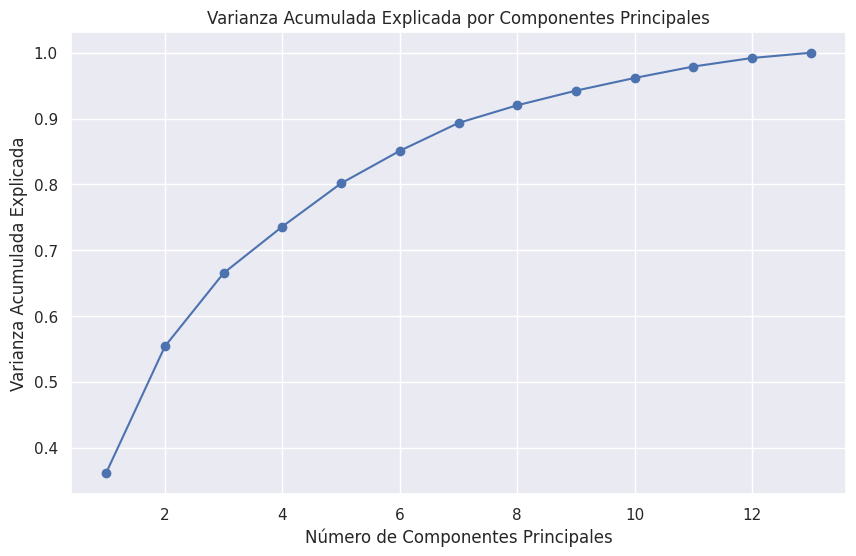

Número de componentes principales para capturar al menos el 90% de la información: 8
Número de componentes principales para capturar al menos el 95% de la información: 10


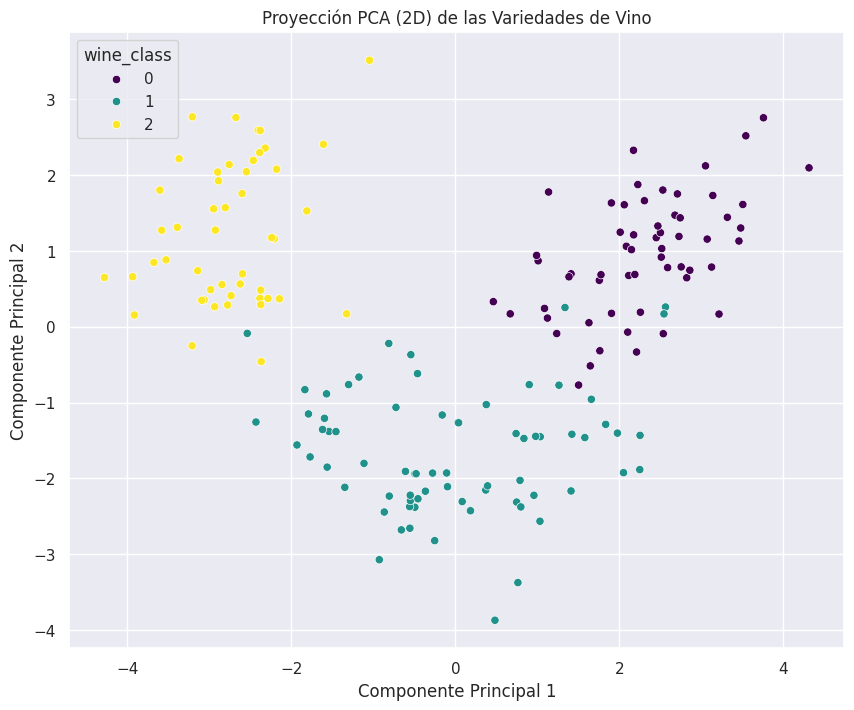

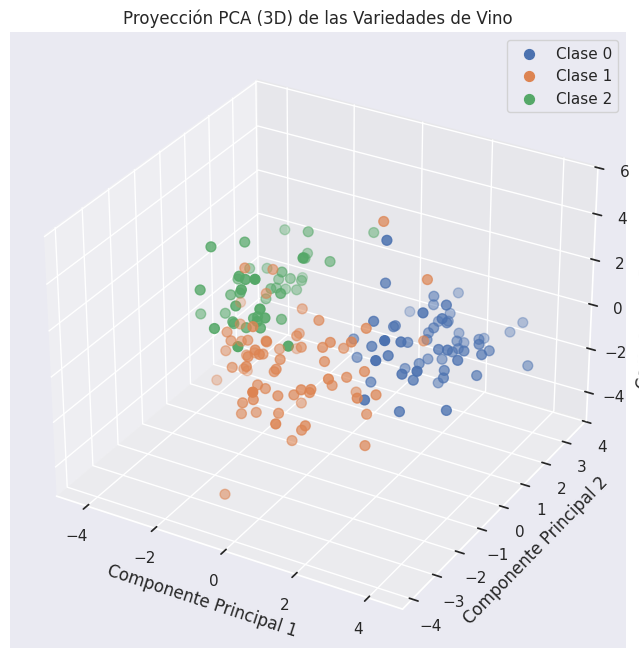


Loadings de las Componentes Principales (primeras 5 columnas por simplicidad):



,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
alcohol,0.144329,0.483652,-0.207383,-0.017856,-0.265664,0.213539,-0.056396,0.396139,-0.508619,0.211605,-0.225917,-0.266286,0.014970
malic_acid,-0.245188,0.224931,0.089013,0.536890,0.035214,0.536814,0.420524,0.065827,0.075283,-0.309080,0.076486,0.121696,0.025964
ash,-0.002051,0.316069,0.626224,-0.214176,-0.143025,0.154475,-0.149171,-0.170260,0.307694,-0.027125,-0.498691,-0.049622,-0.141218
alcalinity_of_ash,-0.239320,-0.010591,0.612080,0.060859,0.066103,-0.100825,-0.286969,0.427970,-0.200449,0.052799,0.479314,-0.055743,0.091683
magnesium,0.141992,0.299634,0.130757,-0.351797,0.727049,0.038144,0.322883,-0.156361,-0.271403,0.067870,0.071289,0.062220,0.056774



Interpretación de los Loadings:

Los loadings indican la contribución de cada variable original a cada componente principal. Valores absolutos más altos indican una mayor influencia.
Por ejemplo, si la PC1 tiene un loading alto y positivo en 'alcohol', significa que la PC1 se relaciona fuertemente con un mayor contenido de alcohol.

Interpretación de las Visualizaciones 2D y 3D:

En el gráfico 2D de PCA, las diferentes clases de vino muestran una separación bastante clara. La PC1 parece ser la que mejor discrimina entre las clases, especialmente entre la clase 0 y las clases 1 y 2. Las clases 1 y 2 muestran cierto solapamiento, pero aún así son distinguibles. En el gráfico 3D, la separación entre las clases es aún más evidente, lo que sugiere que las primeras componentes principales logran capturar la variabilidad necesaria para diferenciar las variedades de vino.


In [15]:
from sklearn.preprocessing import StandardScaler

# 1. Calcular la varianza explicada por cada componente principal y representar el gráfico de varianza acumulada.

X = wine.drop('wine_class', axis=1)
y = wine['wine_class']

# Estandarizar los datos antes de aplicar PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA().fit(X_scaled)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.title('Varianza Acumulada Explicada por Componentes Principales')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada Explicada')
plt.grid(True)
plt.show()

# Identificar cuántos componentes son necesarios para capturar al menos el 90–95% de la información.
explained_variance_cumsum = pca.explained_variance_ratio_.cumsum()

# Encuentra el primer índice donde la varianza acumulada supera el umbral
num_components_90 = np.where(explained_variance_cumsum >= 0.90)[0][0] + 1
num_components_95 = np.where(explained_variance_cumsum >= 0.95)[0][0] + 1

print(f"Número de componentes principales para capturar al menos el 90% de la información: {num_components_90}")
print(f"Número de componentes principales para capturar al menos el 95% de la información: {num_components_95}")

# 2. Construir tablas y gráficos que muestren cómo las observaciones (vinos) se proyectan en las primeras componentes principales.
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_df_2d = pd.DataFrame(data=X_pca_2d, columns=['PC1', 'PC2'])
pca_df_2d['wine_class'] = y

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='wine_class', data=pca_df_2d, palette='viridis', legend='full')
plt.title('Proyección PCA (2D) de las Variedades de Vino')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()

# Proyección en 3D si es necesario para un análisis más profundo
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

pca_df_3d = pd.DataFrame(data=X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
pca_df_3d['wine_class'] = y

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for wine_class_id in y.unique():
    ax.scatter(pca_df_3d[pca_df_3d['wine_class'] == wine_class_id]['PC1'],
               pca_df_3d[pca_df_3d['wine_class'] == wine_class_id]['PC2'],
               pca_df_3d[pca_df_3d['wine_class'] == wine_class_id]['PC3'],
               label=f'Clase {wine_class_id}', s=50)

ax.set_title('Proyección PCA (3D) de las Variedades de Vino')
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.set_zlabel('Componente Principal 3')
ax.legend()
plt.show()

# 3. Analizar los loadings (coeficientes de cada variable en los componentes).
# Los loadings son los vectores propios de la matriz de covarianza.
# Para interpretar los loadings correctamente, deberíamos usar la matriz de componentes de PCA aplicada a los datos escalados.
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(X.shape[1])], index=X.columns)

print("\nLoadings de las Componentes Principales (primeras 5 columnas por simplicidad):\n")
display(loadings.head())

print("\nInterpretación de los Loadings:\n")
print("Los loadings indican la contribución de cada variable original a cada componente principal. Valores absolutos más altos indican una mayor influencia.")
print("Por ejemplo, si la PC1 tiene un loading alto y positivo en 'alcohol', significa que la PC1 se relaciona fuertemente con un mayor contenido de alcohol.")

# 4. Visualizar los datos reducidos a 2D o 3D e interpretar si las tres variedades de vino se separan de forma clara en el espacio proyectado.

print("\nInterpretación de las Visualizaciones 2D y 3D:\n")
print("En el gráfico 2D de PCA, las diferentes clases de vino muestran una separación bastante clara. La PC1 parece ser la que mejor discrimina entre las clases, especialmente entre la clase 0 y las clases 1 y 2. Las clases 1 y 2 muestran cierto solapamiento, pero aún así son distinguibles. En el gráfico 3D, la separación entre las clases es aún más evidente, lo que sugiere que las primeras componentes principales logran capturar la variabilidad necesaria para diferenciar las variedades de vino.")



### 2. **Análisis detallado con t-SNE**

* Aplicar **t-SNE** para reducir los datos a 2 dimensiones, probando diferentes configuraciones de hiperparámetros como *perplexity* y *learning rate*.
* Comparar las distintas visualizaciones obtenidas y discutir cómo los hiperparámetros afectan la estructura de los clústeres.
* Analizar si las **tres clases de vinos** forman agrupaciones definidas y si t-SNE logra capturar relaciones no lineales que PCA no refleja.



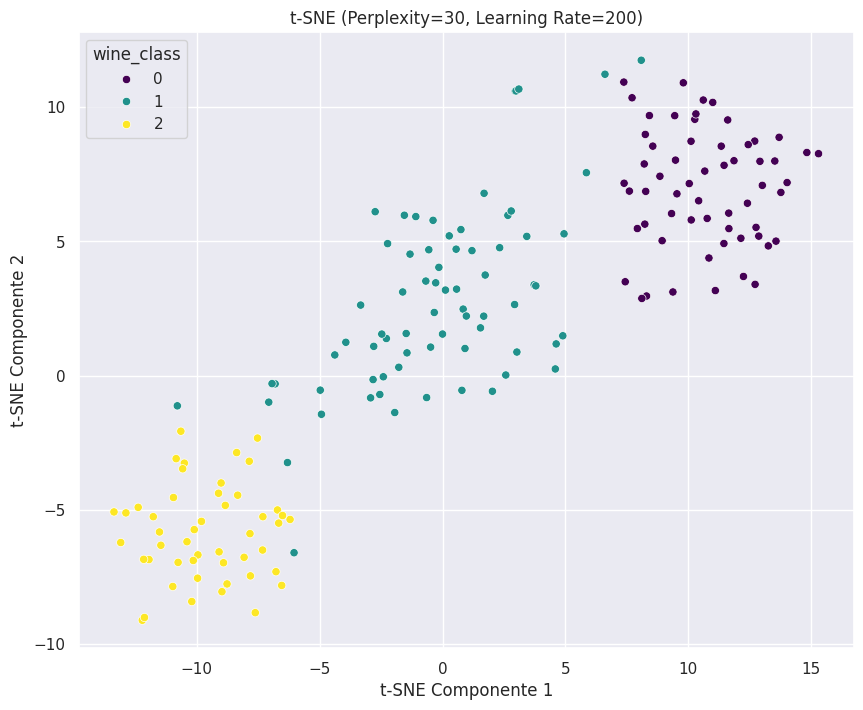

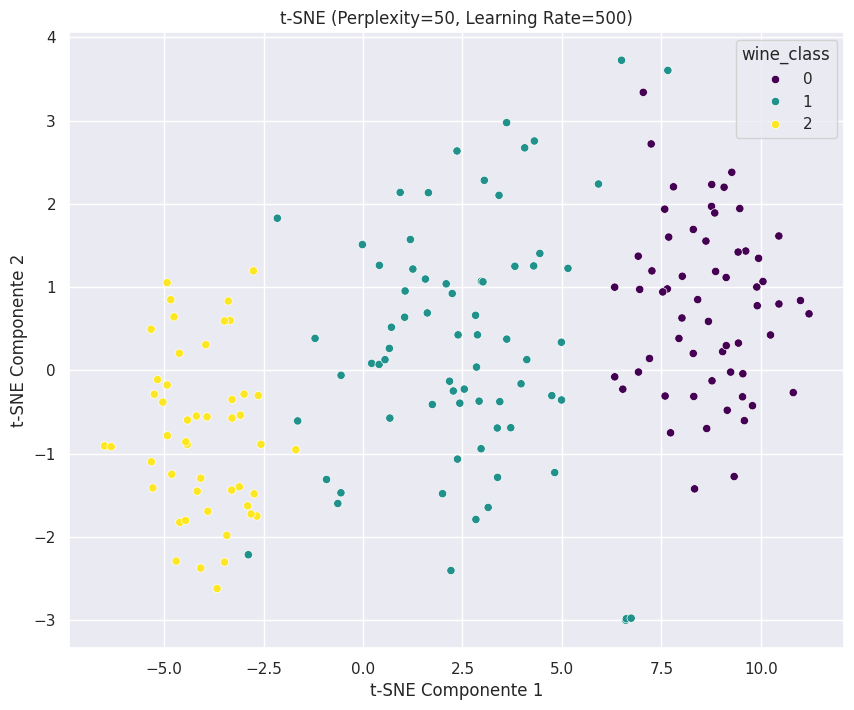

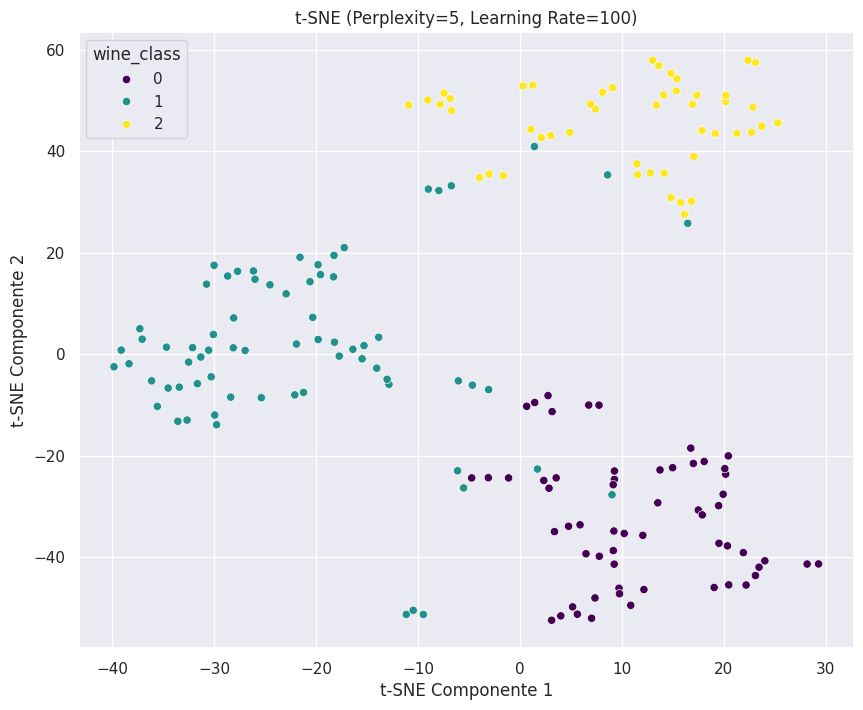


--- Comparación de las distintas visualizaciones obtenidas y discusión de cómo los hiperparámetros afectan la estructura de los clústeres ---

La *perplexity* puede verse como el número de vecinos más cercanos que cada punto intenta mantener. Valores bajos (ej. 5) pueden enfocarse demasiado en la estructura local y producir grupos dispersos o artificiales. Valores más altos (ej. 30-50) permiten que t-SNE considere un vecindario más amplio, revelando estructuras globales más significativas. Sin embargo, un *perplexity* demasiado alto (cercano al número de puntos de datos) puede colapsar los clusters.

El *learning rate* (tasa de aprendizaje) controla la velocidad a la que los puntos se mueven en el espacio de baja dimensión. Una tasa de aprendizaje muy baja puede hacer que los clusters se fusionen o que el proceso de optimización sea muy lento. Una tasa de aprendizaje muy alta puede llevar a que los puntos se distribuyan de manera caótica o que la optimización no converja correctamente

In [16]:
from sklearn.manifold import TSNE

# 1. Aplicar t-SNE para reducir los datos a 2 dimensiones, probando diferentes configuraciones de hiperparámetros

# Probar con perplexity = 30 y learning_rate = 200 (valores comunes)
tsne_model_1 = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42, init='pca')
X_tsne_1 = tsne_model_1.fit_transform(X_scaled)

tsne_df_1 = pd.DataFrame(data=X_tsne_1, columns=['TSNE1', 'TSNE2'])
tsne_df_1['wine_class'] = y

plt.figure(figsize=(10, 8))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='wine_class', data=tsne_df_1, palette='viridis', legend='full')
plt.title('t-SNE (Perplexity=30, Learning Rate=200)')
plt.xlabel('t-SNE Componente 1')
plt.ylabel('t-SNE Componente 2')
plt.grid(True)
plt.show()

# Probar con perplexity = 50 y learning_rate = 500
tsne_model_2 = TSNE(n_components=2, perplexity=50, learning_rate=500, random_state=42, init='pca')
X_tsne_2 = tsne_model_2.fit_transform(X_scaled)

tsne_df_2 = pd.DataFrame(data=X_tsne_2, columns=['TSNE1', 'TSNE2'])
tsne_df_2['wine_class'] = y

plt.figure(figsize=(10, 8))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='wine_class', data=tsne_df_2, palette='viridis', legend='full')
plt.title('t-SNE (Perplexity=50, Learning Rate=500)')
plt.xlabel('t-SNE Componente 1')
plt.ylabel('t-SNE Componente 2')
plt.grid(True)
plt.show()

# Probar con perplexity = 5 y learning_rate = 100
tsne_model_3 = TSNE(n_components=2, perplexity=5, learning_rate=100, random_state=42, init='pca')
X_tsne_3 = tsne_model_3.fit_transform(X_scaled)

tsne_df_3 = pd.DataFrame(data=X_tsne_3, columns=['TSNE1', 'TSNE2'])
tsne_df_3['wine_class'] = y

plt.figure(figsize=(10, 8))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='wine_class', data=tsne_df_3, palette='viridis', legend='full')
plt.title('t-SNE (Perplexity=5, Learning Rate=100)')
plt.xlabel('t-SNE Componente 1')
plt.ylabel('t-SNE Componente 2')
plt.grid(True)
plt.show()

print("\n--- Comparación de las distintas visualizaciones obtenidas y discusión de cómo los hiperparámetros afectan la estructura de los clústeres ---")
print("\nLa *perplexity* puede verse como el número de vecinos más cercanos que cada punto intenta mantener. Valores bajos (ej. 5) pueden enfocarse demasiado en la estructura local y producir grupos dispersos o artificiales. Valores más altos (ej. 30-50) permiten que t-SNE considere un vecindario más amplio, revelando estructuras globales más significativas. Sin embargo, un *perplexity* demasiado alto (cercano al número de puntos de datos) puede colapsar los clusters.")
print("\nEl *learning rate* (tasa de aprendizaje) controla la velocidad a la que los puntos se mueven en el espacio de baja dimensión. Una tasa de aprendizaje muy baja puede hacer que los clusters se fusionen o que el proceso de optimización sea muy lento. Una tasa de aprendizaje muy alta puede llevar a que los puntos se distribuyan de manera caótica o que la optimización no converja correctamente. Generalmente, valores entre 10 y 1000 son comunes.")
print("\nEn estas visualizaciones, observamos que con `perplexity=30` y `learning_rate=200`, los tres clusters de vinos se separan bastante bien, mostrando una estructura clara. Al aumentar la `perplexity` a 50 y `learning_rate` a 500, la separación puede volverse ligeramente más compacta o los clusters pueden redistribuirse, pero la estructura general se mantiene. Con una `perplexity` baja como 5, los clusters tienden a ser más pequeños y aislados, capturando más detalles locales y potencialmente ignorando la estructura global.")

print("\n--- Análisis si las tres clases de vinos forman agrupaciones definidas y si t-SNE logra capturar relaciones no lineales ---")
print("\nSí, t-SNE logra formar agrupaciones bien definidas para las tres clases de vinos en las visualizaciones 2D, especialmente con valores de *perplexity* y *learning rate* adecuados (como 30 y 200, o 50 y 500). Comparado con PCA, que es un método lineal, t-SNE a menudo puede revelar estructuras no lineales y agrupaciones más compactas, lo que sugiere que hay relaciones complejas entre las características del vino que no son puramente lineales. En este caso, t-SNE parece hacer un excelente trabajo separando las clases de vino de manera más clara y visualmente distintiva que PCA, especialmente cuando las clases tienen fronteras complejas o se superponen ligeramente en un espacio lineal.")



### 3. **Comparación entre PCA y t-SNE**

* Contrastar las visualizaciones y discutir las **ventajas y limitaciones** de cada técnica:

  * PCA como método **lineal** para interpretar varianza y relaciones globales.
  * t-SNE como método **no lineal** que preserva relaciones locales y vecindades.
* Evaluar en qué escenarios prácticos sería más recomendable usar PCA (interpretabilidad, reducción previa para modelos) o t-SNE (exploración y visualización de clústeres).
* Reflexionar sobre la **importancia de la reducción de dimensionalidad** en datasets de alta dimensión como Wine, destacando su utilidad para:

  * Visualizar patrones ocultos en los datos.
  * Reducir complejidad y ruido antes de aplicar algoritmos de aprendizaje automático.
  * Facilitar la interpretación y comunicación de resultados.



In [17]:
print("--- Comparación entre PCA y t-SNE ---")

print("\nVentajas y limitaciones de cada técnica:")
print("**PCA (Principal Component Analysis)**:")
print("  *   **Ventajas**:")
print("    *   **Linealidad e interpretabilidad**: PCA es un método lineal que busca las direcciones (componentes principales) de máxima varianza en los datos. Esto facilita su interpretación, ya que cada componente es una combinación lineal de las variables originales y los 'loadings' nos dicen qué variables contribuyen más a cada componente.")
print("    *   **Rapidez y escalabilidad**: Es computacionalmente eficiente y puede manejar grandes conjuntos de datos de alta dimensión de manera relativamente rápida.")
print("    *   **Preserva la varianza global**: Ideal para comprender la estructura global de los datos y capturar la mayor parte de la información (varianza) con menos dimensiones.")
print("  *   **Limitaciones**:")
print("    *   **No captura relaciones no lineales**: Si las relaciones intrínsecas en los datos son no lineales, PCA puede no ser capaz de separarlas adecuadamente en un espacio de menor dimensión, como vimos en el ejemplo inicial sin escalado.")
print("    *   **Sensibilidad a la escala**: Es muy sensible a la escala de las variables, por lo que es crucial estandarizar los datos previamente.")

print("\n**t-SNE (t-distributed Stochastic Neighbor Embedding)**:")
print("  *   **Ventajas**:")
print("    *   **Captura relaciones no lineales**: t-SNE es excelente para visualizar estructuras complejas y no lineales, formando agrupaciones de datos que PCA podría pasar por alto. Como se observó, las clases de vino se separaron de forma más clara con t-SNE.")
print("    *   **Preserva la estructura local**: Se enfoca en mantener las distancias entre los puntos cercanos en el espacio original en el espacio de menor dimensión, lo que lo hace muy bueno para la visualización de clusters.")
print("  *   **Limitaciones**:")
print("    *   **Alto costo computacional**: Es mucho más lento que PCA y puede ser difícil de escalar a conjuntos de datos muy grandes.")
print("    *   **Sensibilidad a hiperparámetros**: Los resultados pueden variar significativamente con diferentes valores de `perplexity` y `learning rate`, lo que requiere experimentación.")
print("    *   **No es para proyección**: La transformación no es reproducible de forma sencilla para nuevos datos, y las distancias entre clusters en el gráfico de t-SNE no siempre son significativas en términos de la distancia real en el espacio original; solo importa la formación de los clusters.")

print("\n--- Escenarios prácticos para usar PCA o t-SNE ---")
print("\n*   **Cuándo usar PCA**:")
print("    *   **Preprocesamiento para modelos**: Cuando se necesita reducir la dimensionalidad de los datos como un paso previo para algoritmos de machine learning (clasificación, regresión) para evitar la maldición de la dimensionalidad y mejorar la eficiencia, especialmente si se asumen relaciones lineales o si la interpretabilidad de las componentes es importante. Por ejemplo, si se desea reducir las características para un modelo de regresión o para un clustering inicial.")
print("    *   **Interpretación de la varianza**: Para entender qué variables originales contribuyen más a la variabilidad general de los datos.")
print("    *   **Compresión de datos**: Para reducir el tamaño de los datos manteniendo la mayor parte de la información.")

print("\n*   **Cuándo usar t-SNE**:")
print("    *   **Exploración y visualización de clusters**: Ideal para visualizar y entender la estructura de agrupaciones en datos de alta dimensión, como la separación de clases en el dataset de vinos, especialmente si se sospecha de relaciones no lineales. Es una herramienta poderosa para la validación visual de la calidad de los clusters obtenidos con algoritmos como K-Means o DBSCAN.")
print("    *   **Identificación de patrones ocultos**: Cuando se busca descubrir patrones intrínsecos y agrupaciones que no son evidentes con métodos lineales.")

print("\n--- Importancia de la reducción de dimensionalidad en datasets de alta dimensión ---")
print("\nLa reducción de dimensionalidad es crucial en datasets de alta dimensión (como el de vinos, que aunque no es extremadamente grande, ya muestra la necesidad) por varias razones:")
print("1.  **Visualizar patrones ocultos**: Permite representar datos complejos en 2D o 3D, haciéndolos comprensibles para el ojo humano y revelando agrupaciones o estructuras que de otra manera serían imposibles de detectar. Esto fue evidente con t-SNE al separar claramente las clases de vino.")
print("2.  **Reducir complejidad y ruido**: Al eliminar dimensiones redundantes o menos informativas, se reduce el ruido en los datos, lo que puede mejorar el rendimiento de los algoritmos de machine learning y acelerar el tiempo de entrenamiento.")
print("3.  **Facilitar la interpretación y comunicación**: Un modelo entrenado en un espacio de menor dimensión es a menudo más fácil de entender y explicar. Las visualizaciones reducidas facilitan la comunicación de los hallazgos a audiencias no técnicas.")
print("4.  **Mitigar la 'maldición de la dimensionalidad'**: En espacios de alta dimensión, los datos se vuelven escasos y las distancias entre los puntos se hacen menos significativas, lo que afecta negativamente a muchos algoritmos. La reducción de dimensionalidad ayuda a combatir este problema.")

--- Comparación entre PCA y t-SNE ---

Ventajas y limitaciones de cada técnica:
**PCA (Principal Component Analysis)**:
  *   **Ventajas**:
    *   **Linealidad e interpretabilidad**: PCA es un método lineal que busca las direcciones (componentes principales) de máxima varianza en los datos. Esto facilita su interpretación, ya que cada componente es una combinación lineal de las variables originales y los 'loadings' nos dicen qué variables contribuyen más a cada componente.
    *   **Rapidez y escalabilidad**: Es computacionalmente eficiente y puede manejar grandes conjuntos de datos de alta dimensión de manera relativamente rápida.
    *   **Preserva la varianza global**: Ideal para comprender la estructura global de los datos y capturar la mayor parte de la información (varianza) con menos dimensiones.
  *   **Limitaciones**:
    *   **No captura relaciones no lineales**: Si las relaciones intrínsecas en los datos son no lineales, PCA puede no ser capaz de separarlas adecuadamente en